In [65]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB

In [16]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
    )

In [17]:
import matplotlib.pyplot as plt

In [18]:
df = pd.read_csv("studentt.csv")
print(df)

   student_id  age  gender  studyhours  attendance  marks result
0           1   18    Male           4          92     85   Pass
1           2   19  Female           6          95     91   Pass
2           3   18    Male          78          62     85   Pass
3           4   20  Female           7          98     92   Pass
4           5   19    Male           3          85     85   Pass
5           6   18  Female           1          65     83   Fail
6           7   21    Male           5          90     88   Pass
7           8   20    Male           2          70     55   Pass
8           9   19    Male           1          60     38   Fail
9          10   18  Female           6          96     80   Pass


In [19]:
print(df.head())

   student_id  age  gender  studyhours  attendance  marks result
0           1   18    Male           4          92     85   Pass
1           2   19  Female           6          95     91   Pass
2           3   18    Male          78          62     85   Pass
3           4   20  Female           7          98     92   Pass
4           5   19    Male           3          85     85   Pass


In [31]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   student_id  10 non-null     int64 
 1   age         10 non-null     int64 
 2   gender      10 non-null     object
 3   studyhours  10 non-null     int64 
 4   attendance  10 non-null     int64 
 5   marks       10 non-null     int64 
 6   result      10 non-null     object
dtypes: int64(5), object(2)
memory usage: 692.0+ bytes
None


In [21]:
print(df.isnull().sum())

student_id    0
age           0
gender        0
studyhours    0
attendance    0
marks         0
result        0
dtype: int64


In [22]:
df.fillna(df.mean(numeric_only=True),inplace=True)

In [23]:
print(df.isnull().sum())

student_id    0
age           0
gender        0
studyhours    0
attendance    0
marks         0
result        0
dtype: int64


In [24]:
df.fillna(df.mean(numeric_only=True),inplace=True)

In [25]:
print(df.isnull().sum())

student_id    0
age           0
gender        0
studyhours    0
attendance    0
marks         0
result        0
dtype: int64


In [26]:
x=df[["age","studyhours","attendance","marks"]]

In [27]:
y=df['result']

In [28]:
encoder = LabelEncoder()
y = encoder.fit_transform(y)
print(y)

[1 1 1 1 1 0 1 1 0 1]


In [36]:
encoder.fit_transform(y)

array([1, 1, 1, 1, 1, 0, 1, 1, 0, 1])

In [37]:
x_train,x_test,y_train,y_test=train_test_split(
    x,y,
    test_size=0.2,
    random_state=42,
    stratify=y)

In [38]:
print("Training samples:",len(x_train))

Training samples: 8


In [39]:
print("teststing samples:",len(x_test))

teststing samples: 2


In [40]:
model = DecisionTreeClassifier(random_state=42)

In [41]:
model.fit(x_train,y_train)

DecisionTreeClassifier(random_state=42)

In [66]:
nb_model = GaussianNB()
nb_model.fit(x_train, y_train)
print("Naive Bayes model training complete.")

Naive Bayes model training complete.


In [67]:
y_pred_nb = nb_model.predict(x_test)
print("Naive Bayes predictions:", y_pred_nb)

Naive Bayes predictions: [1 1]


In [70]:
accuracy_nb = accuracy_score(y_test, y_pred_nb)
precision_nb = precision_score(y_test, y_pred_nb, zero_division=0)
recall_nb = recall_score(y_test, y_pred_nb, zero_division=0)
f1_nb = f1_score(y_test, y_pred_nb, zero_division=0)

print("\n--- Naive Bayes Metrics ---")
print(f"Accuracy (Naive Bayes): {accuracy_nb:.2f}")
print(f"Precision (Naive Bayes): {precision_nb:.2f}")
print(f"Recall (Naive Bayes): {recall_nb:.2f}")
print(f"F1 Score (Naive Bayes): {f1_nb:.2f}")



--- Naive Bayes Metrics ---
Accuracy (Naive Bayes): 1.00
Precision (Naive Bayes): 1.00
Recall (Naive Bayes): 1.00
F1 Score (Naive Bayes): 1.00


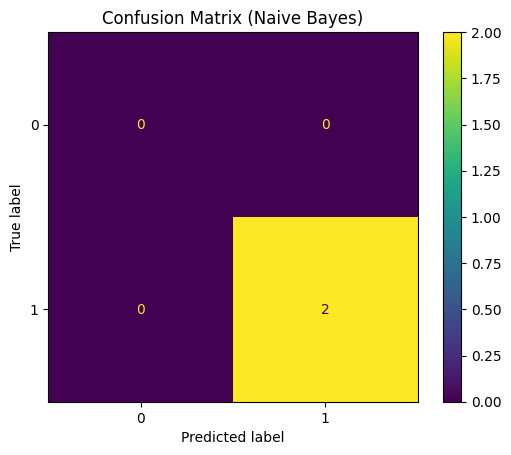

In [69]:
cm_nb = confusion_matrix(y_test, y_pred_nb, labels=encoder.transform(encoder.classes_))
disp_nb = ConfusionMatrixDisplay(confusion_matrix=cm_nb, display_labels=encoder.classes_)
disp_nb.plot()
plt.title("Confusion Matrix (Naive Bayes)")
plt.show()

In [42]:
y_pred=model.predict(x_test)

In [44]:
print("actual:",y_test)
print("Predicted:",y_pred)

actual: [1 1]
Predicted: [1 1]


In [45]:
accuracy=accuracy_score(y_test,y_pred)

In [46]:
print("Accuracy:",accuracy)

Accuracy: 1.0


In [47]:
precision =  precision_score(y_test,y_pred,zero_division=0)

In [48]:
print("precision:",precision)

precision: 1.0


In [64]:
recall = recall_score(y_test,y_pred,zero_division=0)

In [50]:
print("Recall:",recall)

Recall: 1.0


In [52]:
f1=f1_score(y_test,y_pred,zero_division=0)
print("F1 Score:",f1)

F1 Score: 1.0


In [62]:
cm = confusion_matrix(y_test,y_pred,labels=encoder.transform(encoder.classes_))

print("confusion matrix:")
print(cm)

confusion matrix:
[[0 0]
 [0 2]]


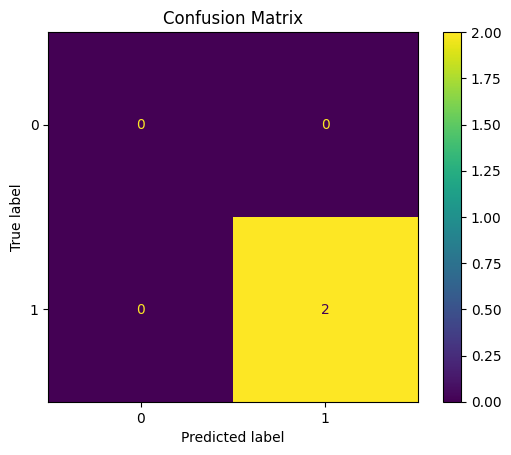

In [63]:
disp=ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=encoder.classes_
)

disp.plot()
plt.title("Confusion Matrix")
plt.show()

In [71]:
print("\n--- Decision Tree Metrics ---")
print(f"Accuracy (Decision Tree): {accuracy:.2f}")
print(f"Precision (Decision Tree): {precision:.2f}")
print(f"Recall (Decision Tree): {recall:.2f}")
print(f"F1 Score (Decision Tree): {f1:.2f}")


--- Decision Tree Metrics ---
Accuracy (Decision Tree): 1.00
Precision (Decision Tree): 1.00
Recall (Decision Tree): 1.00
F1 Score (Decision Tree): 1.00
